
# Classification — Theory, Math & Code

A companion notebook to the animated slide deck. Where the deck builds *intuition*, this notebook derives the
**math from first principles** and backs every equation with a **working implementation** you can run, break, and
inspect.

Every algorithm below is fit on the **same synthetic dataset** (unless noted otherwise) so you can compare their
decision boundaries directly — same data, different lens.

**Contents**

1. [What Is Classification?](#1.-What-Is-Classification?)
2. [Bias-Variance Tradeoff](#2.-Bias-Variance-Tradeoff)
3. [Train/Test Split & Cross-Validation](#3.-Train-Test-Split-&-Cross-Validation)
4. [Feature Scaling](#4.-Feature-Scaling)
5. [Logistic Regression](#5.-Logistic-Regression)
6. [K-Nearest Neighbors](#6.-K-Nearest-Neighbors-(KNN))
7. [Support Vector Machine](#7.-Support-Vector-Machine-(SVM))
8. [Decision Tree](#8.-Decision-Tree)
9. [Random Forest & Extra Trees](#9.-Random-Forest-&-Extra-Trees)
10. [Naive Bayes](#10.-Naive-Bayes)
11. [LDA & QDA](#11.-Linear-&-Quadratic-Discriminant-Analysis)
12. [Perceptron](#12.-Perceptron)
13. [Neural Network (MLP)](#13.-Neural-Network-(MLP))
14. [Gradient Boosting](#14.-Gradient-Boosting)
15. [AdaBoost](#15.-AdaBoost)
16. [XGBoost, LightGBM, CatBoost](#16.-XGBoost,-LightGBM,-CatBoost)
17. [SGD Classifier](#17.-Stochastic-Gradient-Descent-(SGD)-Classifier)
18. [Regularization (L1 vs L2)](#18.-Regularization-(L1-vs-L2))
19. [Multi-Class Strategies](#19.-Multi-Class-Strategies)
20. [Confusion Matrix, Precision, Recall, F1](#20.-Confusion-Matrix,-Precision,-Recall,-F1)
21. [ROC Curve & AUC](#21.-ROC-Curve-&-AUC)
22. [Summary Cheat Sheet](#22.-Summary-Cheat-Sheet)



## Setup

Shared imports, plotting helpers, and the datasets every later section reuses.


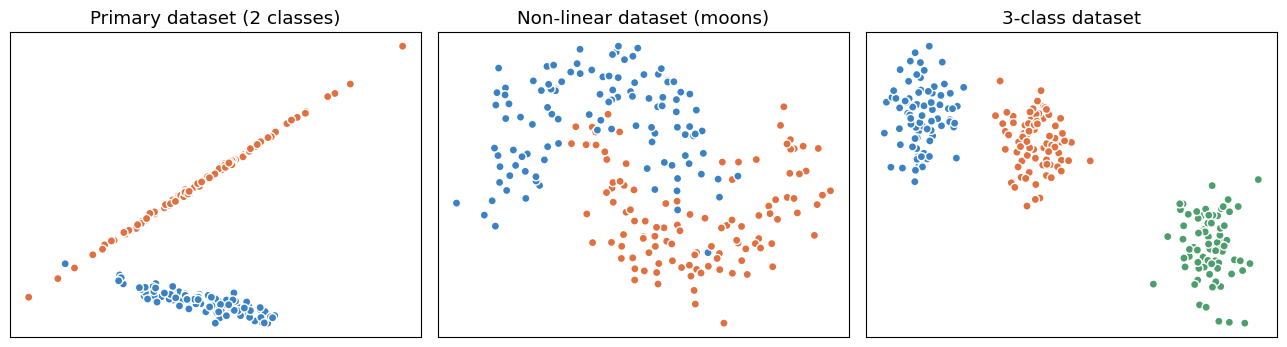

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_classification, make_blobs, make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['font.size'] = 11

# palette (mirrors the slide deck)
COLOR_A, COLOR_B, COLOR_C = '#3B82C4', '#E0703F', '#4E9E6D'
CMAP_LIGHT = ListedColormap(['#dceafc', '#fbe3d4'])
CMAP_LIGHT3 = ListedColormap(['#dceafc', '#fbe3d4', '#ddf0e2'])
CMAP_BOLD  = ListedColormap([COLOR_A, COLOR_B])
CMAP_BOLD3 = ListedColormap([COLOR_A, COLOR_B, COLOR_C])


def plot_boundary(model, X, y, title="", ax=None, cmap_light=CMAP_LIGHT, cmap_bold=CMAP_BOLD, proba_class=None):
    """Fit-agnostic decision-boundary plotter: draws the model's predicted regions
    as filled contours, with the actual points scattered on top."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4.2))
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    if proba_class is not None and hasattr(model, "predict_proba"):
        Z = model.predict_proba(grid)[:, proba_class]
    else:
        Z = model.predict(grid)
        Z = np.asarray(Z).astype(float)
    Z = Z.reshape(xx.shape)
    if proba_class is not None:
        ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 11), cmap='RdBu_r', alpha=0.55)
    else:
        ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.85)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='white', linewidth=0.6, s=38, zorder=3)
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    return ax


# --- Shared 2-class dataset used by most sections ---
X, y = make_classification(
    n_samples=220, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.6, flip_y=0.03, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# --- A non-linearly-separable dataset, for kernel / nonlinear demos ---
X_moon, y_moon = make_moons(n_samples=220, noise=0.22, random_state=42)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_moon, y_moon, test_size=0.25, random_state=42, stratify=y_moon)

# --- A 3-class dataset, for multi-class demos ---
X3, y3 = make_blobs(n_samples=240, centers=3, cluster_std=1.15, random_state=7)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP_BOLD, edgecolor='white', s=35)
axes[0].set_title('Primary dataset (2 classes)'); axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap=CMAP_BOLD, edgecolor='white', s=35)
axes[1].set_title('Non-linear dataset (moons)'); axes[1].set_xticks([]); axes[1].set_yticks([])
axes[2].scatter(X3[:, 0], X3[:, 1], c=y3, cmap=CMAP_BOLD3, edgecolor='white', s=35)
axes[2].set_title('3-class dataset'); axes[2].set_xticks([]); axes[2].set_yticks([])
plt.tight_layout(); plt.show()



## 1. What Is Classification?

Classification is **supervised learning** where the target $y$ is discrete. Formally, we want to learn a function

$$f: \mathbb{R}^n \rightarrow \{0, 1, \dots, k\}$$

from a training set of $(x_i, y_i)$ pairs, such that $f$ generalizes to unseen $x$. Every algorithm in this notebook
is a different strategy for constructing $f$ — a different way of carving up $\mathbb{R}^n$ into regions, one region
per class.

**Types**

| Type | Description | Example |
|---|---|---|
| Binary | 2 classes | spam vs. not spam |
| Multi-class | 1 label out of $k$ | digit 0–9 |
| Multi-label | several labels at once | a movie tagged both "comedy" and "romance" |

**Why we frame it as a function.** Once classification is "just" function approximation, the entire toolbox of
calculus and optimization becomes available: define a loss function that measures how wrong $f$ is, and use
gradients (or combinatorial search, for trees) to reduce that loss.



## 2. Bias-Variance Tradeoff

For a model $\hat f$ trained on random training data, the expected squared error on a fresh point decomposes as:

$$\mathbb{E}\big[(y - \hat f(x))^2\big] = \underbrace{\big(\text{Bias}[\hat f(x)]\big)^2}_{\text{too simple}} + \underbrace{\text{Var}[\hat f(x)]}_{\text{too sensitive}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

**Derivation sketch.** Let $\bar f(x) = \mathbb{E}[\hat f(x)]$ be the average prediction over many training sets.
Add and subtract $\bar f(x)$ inside the square and expand — the cross term vanishes in expectation, leaving exactly
these three non-negative pieces. That's *why* you can never force all three to zero simultaneously: pushing
flexibility down to kill variance drives bias up, and vice versa.

- **High bias** (underfitting): model is too rigid. Fix → more features, more flexible model, less regularization.
- **High variance** (overfitting): model chases noise. Fix → more data, regularization, simpler model, ensembling (bagging).

Below, we make this concrete with polynomial classifiers of increasing complexity.


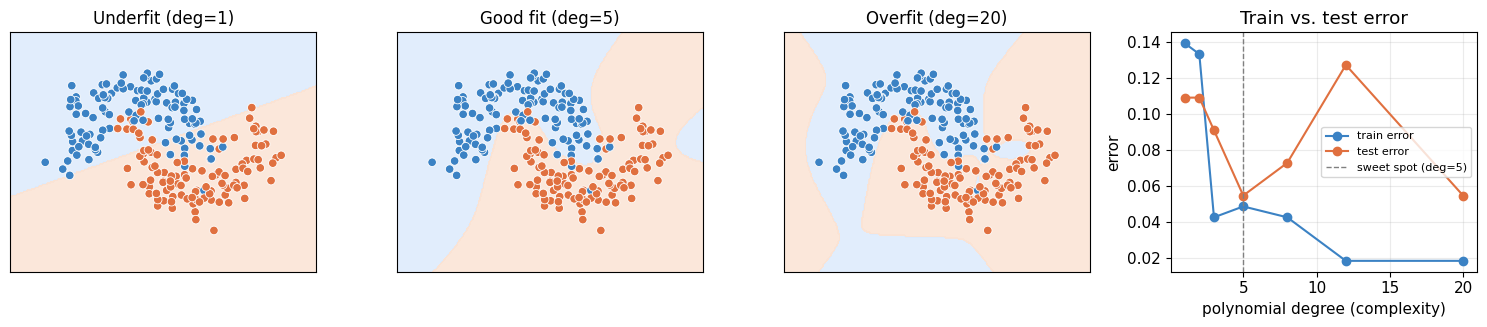

Lowest test error at degree: 5


In [2]:

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# Moons is genuinely non-linear, so a degree-1 model must underfit and a very
# high degree will overfit -- this produces a real U-shaped test error curve.
degrees = [1, 2, 3, 5, 8, 12, 20]
train_err, test_err = [], []
for d in degrees:
    model = make_pipeline(PolynomialFeatures(degree=d), LogisticRegression(max_iter=3000, C=1e3))
    model.fit(Xm_train, ym_train)
    train_err.append(1 - accuracy_score(ym_train, model.predict(Xm_train)))
    test_err.append(1 - accuracy_score(ym_test, model.predict(Xm_test)))

best_degree = degrees[int(np.argmin(test_err))]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, d in zip(axes[:3], [1, best_degree, 20]):
    model = make_pipeline(PolynomialFeatures(degree=d), LogisticRegression(max_iter=3000, C=1e3))
    model.fit(Xm_train, ym_train)
    label = {1: 'Underfit (deg=1)', 20: 'Overfit (deg=20)'}.get(d, f'Good fit (deg={d})')
    plot_boundary(model, X_moon, y_moon, title=label, ax=ax)

axes[3].plot(degrees, train_err, 'o-', color=COLOR_A, label='train error')
axes[3].plot(degrees, test_err, 'o-', color=COLOR_B, label='test error')
axes[3].axvline(best_degree, color='gray', ls='--', lw=1, label=f'sweet spot (deg={best_degree})')
axes[3].set_xlabel('polynomial degree (complexity)'); axes[3].set_ylabel('error')
axes[3].set_title('Train vs. test error'); axes[3].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Lowest test error at degree:", best_degree)



## 3. Train/Test Split & Cross-Validation

A model must be scored on data it never trained on, or the score is meaningless — it's an open-book exam graded
with the answer key already memorized.

**k-fold cross-validation.** Split the data into $k$ folds. For each fold $i$, train on the other $k-1$ folds and
test on fold $i$. Average the results:

$$\text{CV error} = \frac{1}{k}\sum_{i=1}^{k} \text{error}_i$$

**Why averaging helps.** A single train/test split is one noisy sample of "how good is this model." Averaging $k$
roughly-independent estimates reduces that noise by a factor of about $\sqrt{k}$ — the same law of large numbers
that makes polling more people give a steadier estimate than polling one.

**Stratified** splitting preserves each class's proportion in every fold — essential when classes are imbalanced.


Per-fold accuracy: [1.    1.    1.    1.    0.977]
CV mean accuracy: 0.995  (+/- 0.009)


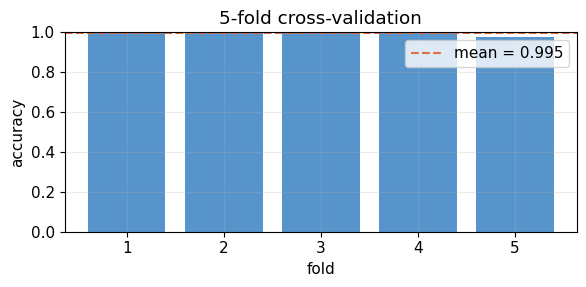

In [3]:

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC

model = SVC(kernel='rbf', gamma='scale')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=skf)

print("Per-fold accuracy:", np.round(scores, 3))
print(f"CV mean accuracy: {scores.mean():.3f}  (+/- {scores.std():.3f})")

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, 6), scores, color=COLOR_A, alpha=0.85)
ax.axhline(scores.mean(), color=COLOR_B, linestyle='--', label=f'mean = {scores.mean():.3f}')
ax.set_xlabel('fold'); ax.set_ylabel('accuracy'); ax.set_ylim(0, 1)
ax.set_title('5-fold cross-validation'); ax.legend()
plt.tight_layout(); plt.show()



## 4. Feature Scaling

**Standardization** rescales each feature to zero mean, unit variance:

$$x' = \frac{x - \mu}{\sigma}$$

**Why.** Distance-based models (KNN, SVM) and gradient-based models (logistic regression, neural nets, SGD) treat
every feature's raw numeric range as meaningful. If one feature spans $[0, 1]$ and another spans $[0, 10{,}000]$,
the second silently dominates any distance calculation or gradient step — not because it's more informative, just
because of its units.

**Min-Max normalization** is the other common choice, rescaling to a fixed range $[0, 1]$:

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Trees (and anything built from trees) don't need this — a split like "$x_1 < t$" is invariant to monotonic
rescaling of $x_1$.


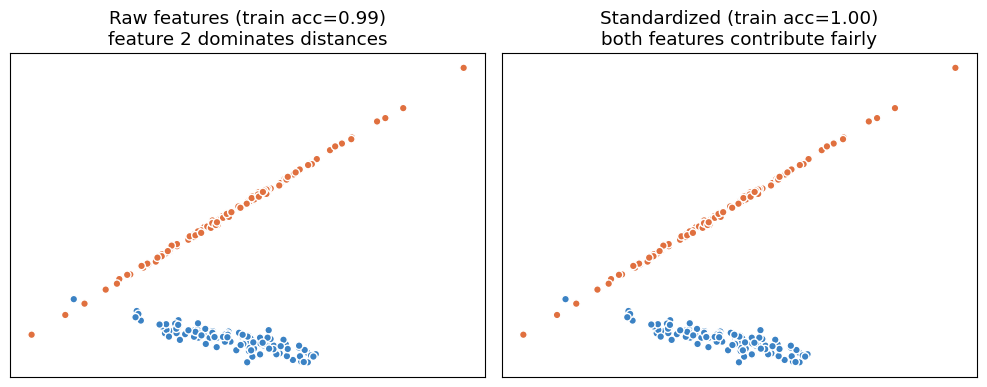

In [4]:

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Simulate a feature-scale mismatch: stretch feature 2 by 300x
X_unscaled = X.copy()
X_unscaled[:, 1] = X_unscaled[:, 1] * 300

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
knn_raw = KNeighborsClassifier(n_neighbors=5).fit(X_unscaled, y)
knn_scaled = KNeighborsClassifier(n_neighbors=5).fit(X_scaled, y)

acc_raw = knn_raw.score(X_unscaled, y)
acc_scaled = knn_scaled.score(X_scaled, y)

axes[0].scatter(X_unscaled[:, 0], X_unscaled[:, 1], c=y, cmap=CMAP_BOLD, edgecolor='white', s=30)
axes[0].set_title(f'Raw features (train acc={acc_raw:.2f})\nfeature 2 dominates distances')
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=CMAP_BOLD, edgecolor='white', s=30)
axes[1].set_title(f'Standardized (train acc={acc_scaled:.2f})\nboth features contribute fairly')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()



## 5. Logistic Regression

**The linear score.** As in linear regression, compute $z = w \cdot x + b$.

**The link function.** $z$ ranges over all of $\mathbb{R}$, but we want a probability in $(0,1)$. The **sigmoid**
function is the fix:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad P(y=1 \mid x) = \sigma(w\cdot x + b)$$

**Why sigmoid specifically?** It's the inverse of the *logit* (log-odds) function:

$$\text{logit}(p) = \log\frac{p}{1-p} = z \quad\Longleftrightarrow\quad p = \sigma(z)$$

So logistic regression is really modeling the **log-odds** of the positive class as a linear function of $x$ — a
natural choice because log-odds, unlike raw probability, is unbounded and symmetric around 0.

**Training.** Maximize the likelihood of the observed labels, equivalently minimize the **log-loss**:

$$\mathcal{L}(w,b) = -\frac{1}{N}\sum_i \big[y_i \log \hat p_i + (1-y_i)\log(1-\hat p_i)\big]$$

This loss is convex in $w$, so gradient descent finds the global optimum.

**Decision boundary.** Predict class 1 when $\sigma(z) \ge 0.5 \iff z \ge 0$ — the boundary $w\cdot x + b = 0$ is a
straight line (hyperplane), regardless of how confident the sigmoid gets far from it.


Test accuracy: 1.000
Learned weights w = [-1.334  2.923], bias b = 2.222


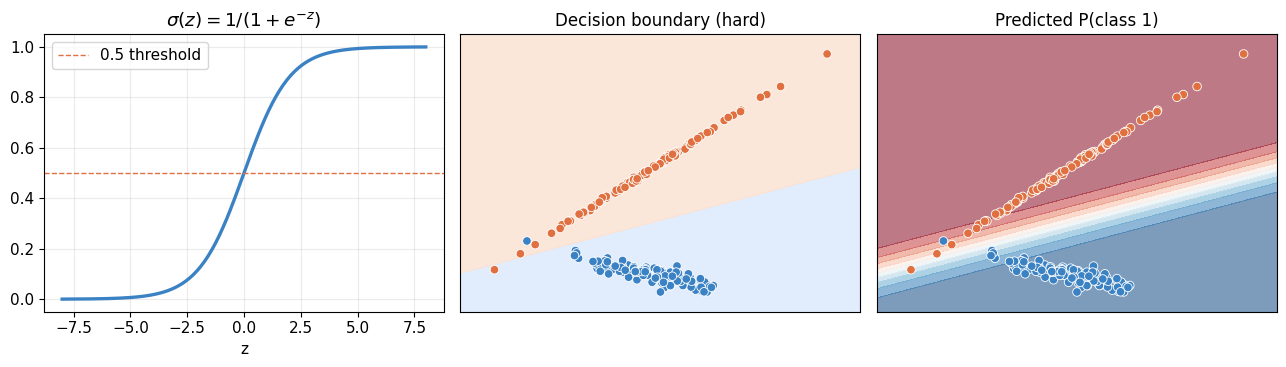

In [5]:

from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression().fit(X_train, y_train)
print(f"Test accuracy: {logreg.score(X_test, y_test):.3f}")
print(f"Learned weights w = {np.round(logreg.coef_[0], 3)}, bias b = {logreg.intercept_[0]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

# sigmoid curve
z = np.linspace(-8, 8, 200)
axes[0].plot(z, 1 / (1 + np.exp(-z)), color=COLOR_A, lw=2.4)
axes[0].axhline(0.5, color=COLOR_B, ls='--', lw=1, label='0.5 threshold')
axes[0].set_title(r'$\sigma(z) = 1/(1+e^{-z})$'); axes[0].set_xlabel('z'); axes[0].legend()

plot_boundary(logreg, X, y, title='Decision boundary (hard)', ax=axes[1])
plot_boundary(logreg, X, y, title='Predicted P(class 1)', ax=axes[2], proba_class=1)

plt.tight_layout(); plt.show()



## 6. K-Nearest Neighbors (KNN)

No parameters are learned at all — "training" is just storing the data. For a new point $x$, find its $k$ nearest
training points $N_k(x)$ (by Euclidean or another distance metric) and let them vote:

$$\hat y = \text{mode}\{y_i : x_i \in N_k(x)\}$$

**Why this works.** It formalizes the assumption that similar inputs have similar outputs — points close together
in feature space likely share a label. That's not guaranteed, but it's a very reasonable prior for most real data.

**Choosing $k$.** Small $k$ → boundary reacts to every point (high variance, jagged). Large $k$ → boundary smooths
out (higher bias). $k$ is usually chosen via cross-validation.

**Curse of dimensionality.** In high dimensions, distances between points become less and less discriminative — the
nearest and farthest neighbor start to look similarly far away. KNN degrades badly without dimensionality reduction
or feature selection first.


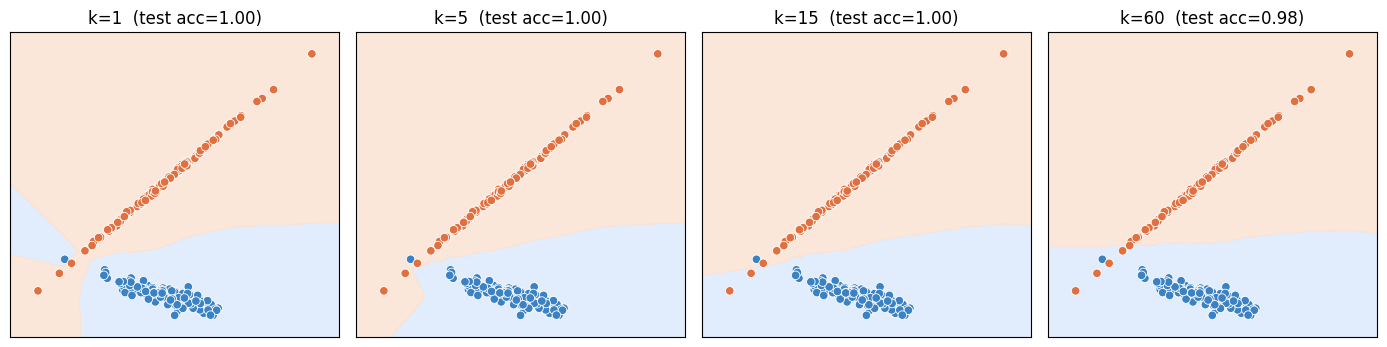

In [6]:

from sklearn.neighbors import KNeighborsClassifier

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, k in zip(axes, [1, 5, 15, 60]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    plot_boundary(knn, X, y, title=f'k={k}  (test acc={acc:.2f})', ax=ax)
plt.tight_layout(); plt.show()



## 7. Support Vector Machine (SVM)

**Objective.** Among all hyperplanes $w\cdot x + b = 0$ that separate the classes, pick the one maximizing the
margin — the distance from the hyperplane to the nearest point of either class.

The perpendicular distance from a point to the hyperplane is $\dfrac{|w\cdot x + b|}{\|w\|}$, so for points sitting
exactly on the margin, the margin width works out to $\dfrac{2}{\|w\|}$. Maximizing that margin is therefore
*identical* to minimizing $\|w\|$:

$$\min_{w,b} \tfrac{1}{2}\|w\|^2 \quad \text{s.t.} \quad y_i(w\cdot x_i + b) \ge 1 \; \forall i$$

(the $\tfrac12$ and squaring are just for calculus convenience — same minimizer).

**Support vectors.** At the optimum, only the points that sit exactly on the margin boundary have non-zero
Lagrange multipliers — they alone determine $w$ and $b$. Every other point could be deleted without changing the
solution.

**The kernel trick.** Real data is rarely linearly separable. Instead of manually engineering new features, replace
every dot product $x_i \cdot x_j$ in the optimization with a **kernel function** $K(x_i, x_j)$ that implicitly
computes the dot product in a much higher-dimensional space — without ever visiting that space explicitly. The RBF
kernel $K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)$ effectively gives infinite-dimensional feature space access.


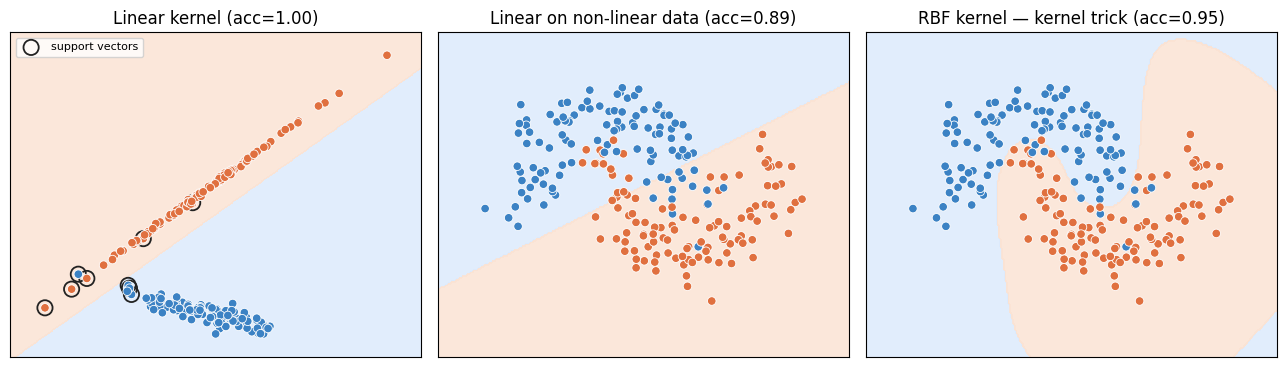

In [7]:

from sklearn.svm import SVC

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

svm_linear = SVC(kernel='linear', C=1.0).fit(X_train, y_train)
plot_boundary(svm_linear, X, y, title=f'Linear kernel (acc={svm_linear.score(X_test,y_test):.2f})', ax=axes[0])
sv = svm_linear.support_vectors_
axes[0].scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='#222', linewidth=1.3, label='support vectors')
axes[0].legend(fontsize=8)

# On the moons dataset: linear kernel fails, RBF succeeds
svm_lin_m = SVC(kernel='linear').fit(Xm_train, ym_train)
svm_rbf_m = SVC(kernel='rbf', gamma=2.0, C=5.0).fit(Xm_train, ym_train)
plot_boundary(svm_lin_m, X_moon, y_moon, title=f'Linear on non-linear data (acc={svm_lin_m.score(Xm_test,ym_test):.2f})', ax=axes[1])
plot_boundary(svm_rbf_m, X_moon, y_moon, title=f'RBF kernel — kernel trick (acc={svm_rbf_m.score(Xm_test,ym_test):.2f})', ax=axes[2])
plt.tight_layout(); plt.show()



## 8. Decision Tree

**The rule.** Recursively split the feature space with axis-aligned questions: *"is $x_j < t$?"*. Each split
creates two child regions; recurse until a stopping condition.

**How a split is scored — Gini impurity:**

$$\text{Gini} = 1 - \sum_{c} p_c^2$$

where $p_c$ is the fraction of class $c$ in a region. **Why this formula:** if you picked a random point from the
region and guessed its label by randomly sampling from the region's own class distribution, Gini is exactly the
probability you'd be wrong. It's $0$ when a region is pure (one class), and maximized at $1 - 1/k$ when classes are
perfectly mixed.

An equivalent alternative is **entropy**: $H = -\sum_c p_c \log_2 p_c$, scored via **information gain**
(reduction in entropy after a split). Both push splits toward purity; Gini is cheaper to compute (no logarithm).

**Choosing the split.** At every node, try every feature and every candidate threshold; keep whichever split
produces the largest *weighted* impurity decrease across the two children.

**Overfitting control:** trees can grow until every leaf is pure (perfectly memorizing training data). Constrain
with `max_depth`, `min_samples_split`, `min_samples_leaf`, or prune after the fact.


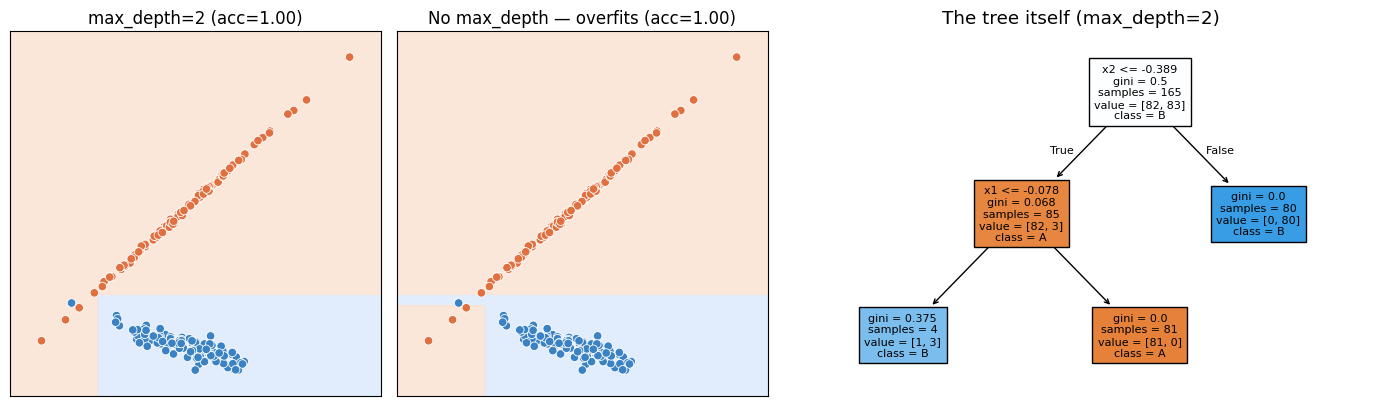

In [8]:

from sklearn.tree import DecisionTreeClassifier, plot_tree

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), gridspec_kw={'width_ratios': [1, 1, 1.6]})

tree_shallow = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_train, y_train)
tree_deep = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_train, y_train)

plot_boundary(tree_shallow, X, y, title=f'max_depth=2 (acc={tree_shallow.score(X_test,y_test):.2f})', ax=axes[0])
plot_boundary(tree_deep, X, y, title=f'No max_depth — overfits (acc={tree_deep.score(X_test,y_test):.2f})', ax=axes[1])

plot_tree(tree_shallow, filled=True, feature_names=['x1', 'x2'], class_names=['A', 'B'], ax=axes[2], fontsize=8)
axes[2].set_title('The tree itself (max_depth=2)')
plt.tight_layout(); plt.show()



## 9. Random Forest & Extra Trees

**Bagging (Bootstrap Aggregating).** Train many trees, each on a random bootstrap sample of the data, then average
(or vote):

$$\hat y = \text{majority\_vote}\big(T_1(x), \dots, T_n(x)\big)$$

**Why averaging helps — the math.** If $n$ predictors each have variance $\sigma^2$ and are pairwise correlated by
$\rho$, the variance of their average is:

$$\text{Var}\left(\frac{1}{n}\sum_i T_i\right) = \rho\sigma^2 + \frac{1-\rho}{n}\sigma^2$$

As $n \to \infty$ the second term vanishes — so *decorrelating* the trees (not just averaging more of them) is what
actually reduces variance. That's exactly what **Random Forest** buys with its extra randomness: each split only
considers a random subset of features, making individual trees less correlated with each other than plain bagging
would.

**Extra Trees** pushes further — it also picks the split *threshold* randomly (instead of the optimal one),
sacrificing a little per-tree accuracy for even lower correlation and much faster training.

**Out-of-bag (OOB) error.** Each tree's bootstrap sample skips about $1/e \approx 37\%$ of the data — that held-out
slice gives a free, built-in validation estimate without needing a separate test set.


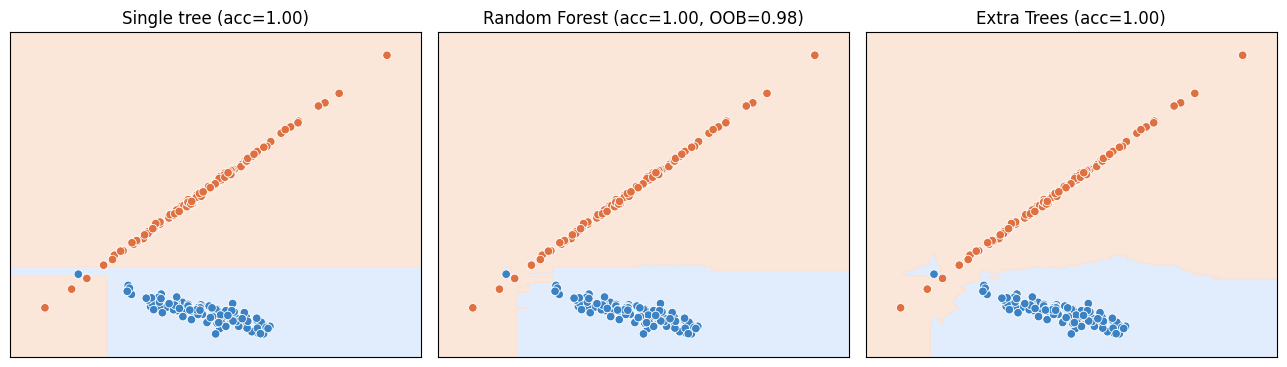

Feature importances (Random Forest): [0.088 0.912]


In [9]:

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

rf = RandomForestClassifier(n_estimators=200, max_features='sqrt', oob_score=True, random_state=42).fit(X_train, y_train)
et = ExtraTreesClassifier(n_estimators=200, random_state=42).fit(X_train, y_train)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
plot_boundary(tree_deep, X, y, title=f'Single tree (acc={tree_deep.score(X_test,y_test):.2f})', ax=axes[0])
plot_boundary(rf, X, y, title=f'Random Forest (acc={rf.score(X_test,y_test):.2f}, OOB={rf.oob_score_:.2f})', ax=axes[1])
plot_boundary(et, X, y, title=f'Extra Trees (acc={et.score(X_test,y_test):.2f})', ax=axes[2])
plt.tight_layout(); plt.show()

print("Feature importances (Random Forest):", np.round(rf.feature_importances_, 3))



## 10. Naive Bayes

**Bayes' theorem** lets us flip a conditional probability:

$$P(y \mid x) = \frac{P(x \mid y)\, P(y)}{P(x)} \;\propto\; P(x \mid y)\, P(y)$$

We know (from training data) how likely certain *features* are given a class; what we actually want is how likely
the *class* is given the features. Bayes' rule is exactly the algebra that performs that inversion.

**The "naive" assumption.** Computing $P(x\mid y)$ for a full feature vector directly is intractable — so Naive
Bayes assumes every feature is conditionally independent given the class:

$$P(x_1,\dots,x_n \mid y) = \prod_{j=1}^n P(x_j \mid y)$$

This is almost always false in the real world, yet Naive Bayes remains a strong baseline — it usually gets the
**ranking** of classes right even when the individual probability estimates are miscalibrated, and that's all
classification needs.

**Three flavors**, differing only in how $P(x_j \mid y)$ is modeled:

| Variant | Feature likelihood | Typical use |
|---|---|---|
| **Gaussian NB** | $P(x_j\mid y) \sim \mathcal N(\mu_{jy}, \sigma_{jy}^2)$ | continuous features |
| **Multinomial NB** | $P(x_j\mid y) \propto \theta_{jy}^{\,x_j}$ (count-based) | word counts / frequencies |
| **Bernoulli NB** | $P(x_j\mid y) = p_{jy}^{x_j}(1-p_{jy})^{1-x_j}$ | binary presence/absence |


MultinomialNB accuracy on synthetic word-count data: 0.93
BernoulliNB accuracy on synthetic presence/absence data: 0.71


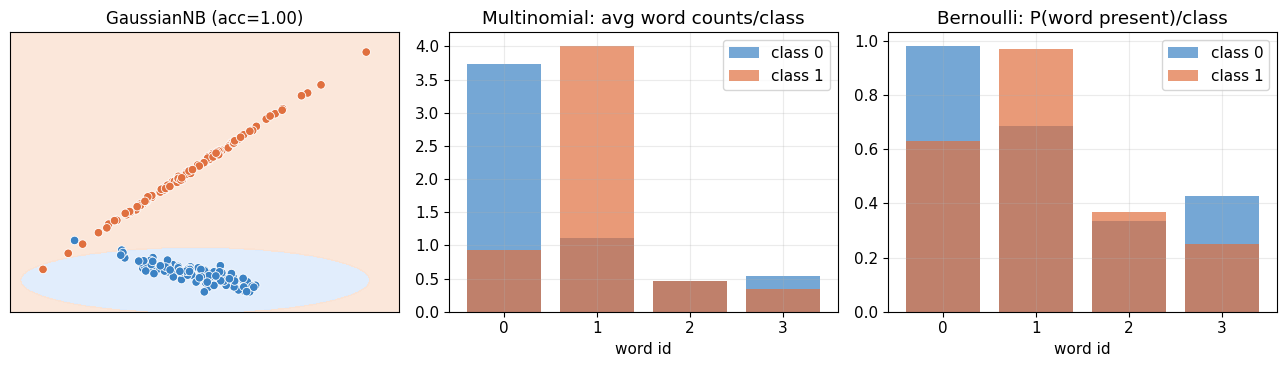

In [10]:

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

gnb = GaussianNB().fit(X_train, y_train)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
plot_boundary(gnb, X, y, title=f'GaussianNB (acc={gnb.score(X_test,y_test):.2f})', ax=axes[0])

# Multinomial / Bernoulli need non-negative / binary features -> simulate a tiny text-style dataset
rng = np.random.RandomState(0)
word_counts = rng.poisson(lam=[3, 1], size=(200, 2)) + rng.poisson(lam=[1, 3], size=(200, 2)) * 0  # placeholder
# Build a clean synthetic "document" word-count dataset: class 0 uses word A often, class 1 uses word B often
y_txt = rng.randint(0, 2, 200)
X_txt = np.zeros((200, 4))
for i, c in enumerate(y_txt):
    X_txt[i] = rng.poisson(lam=[4, 1, 0.5, 0.5]) if c == 0 else rng.poisson(lam=[1, 4, 0.5, 0.5])

mnb = MultinomialNB().fit(X_txt, y_txt)
bnb = BernoulliNB().fit((X_txt > 0).astype(int), y_txt)
print(f"MultinomialNB accuracy on synthetic word-count data: {mnb.score(X_txt, y_txt):.2f}")
print(f"BernoulliNB accuracy on synthetic presence/absence data: {bnb.score((X_txt>0).astype(int), y_txt):.2f}")

axes[1].bar(range(4), X_txt[y_txt==0].mean(axis=0), alpha=0.7, label='class 0', color=COLOR_A)
axes[1].bar(range(4), X_txt[y_txt==1].mean(axis=0), alpha=0.7, label='class 1', color=COLOR_B)
axes[1].set_title('Multinomial: avg word counts/class'); axes[1].set_xlabel('word id'); axes[1].legend()

axes[2].bar(range(4), (X_txt[y_txt==0]>0).mean(axis=0), alpha=0.7, label='class 0', color=COLOR_A)
axes[2].bar(range(4), (X_txt[y_txt==1]>0).mean(axis=0), alpha=0.7, label='class 1', color=COLOR_B)
axes[2].set_title('Bernoulli: P(word present)/class'); axes[2].set_xlabel('word id'); axes[2].legend()
plt.tight_layout(); plt.show()



## 11. Linear & Quadratic Discriminant Analysis

Model each class as a multivariate Gaussian, $x \mid y{=}k \sim \mathcal N(\mu_k, \Sigma_k)$, and classify by
picking the class with the highest posterior. Taking the log of the Gaussian density and dropping constants shared
across classes gives the **discriminant function**:

$$\delta_k(x) = -\tfrac12 (x-\mu_k)^\top \Sigma_k^{-1} (x-\mu_k) - \tfrac12 \log|\Sigma_k| + \log \pi_k$$

predict $\arg\max_k \delta_k(x)$, where $\pi_k$ is the class's prior probability.

**LDA** assumes every class shares one covariance matrix $\Sigma$. The quadratic terms $x^\top\Sigma_k^{-1}x$ then
become identical across classes and cancel when comparing $\delta_k(x) - \delta_j(x)$, leaving a function **linear**
in $x$ — hence a straight decision boundary.

**QDA** keeps a separate $\Sigma_k$ per class. The quadratic term survives the cancellation, so the boundary can
curve.

**The tradeoff:** QDA is more flexible but needs enough data per class to estimate a full covariance matrix
reliably — with few samples, LDA's shared-covariance assumption (fewer parameters) generalizes better.


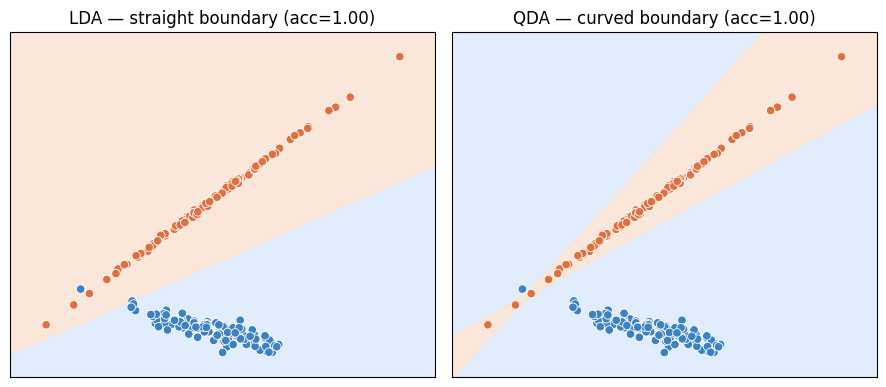

In [11]:

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_boundary(lda, X, y, title=f'LDA — straight boundary (acc={lda.score(X_test,y_test):.2f})', ax=axes[0])
plot_boundary(qda, X, y, title=f'QDA — curved boundary (acc={qda.score(X_test,y_test):.2f})', ax=axes[1])
plt.tight_layout(); plt.show()



## 12. Perceptron

The earliest trainable linear classifier (Rosenblatt, 1958). Predict $\hat y = \text{sign}(w\cdot x + b)$, and
update only on mistakes:

$$w \leftarrow w + \eta\,(y - \hat y)\,x$$

**Why this rule.** If the prediction is already correct, $y - \hat y = 0$ and nothing changes. If it's wrong, the
update nudges $w$ in the direction of $x$ (or away from it) — precisely the smallest linear adjustment that would
flip this one misclassified point to the correct side, without an explicit loss function or gradient computation.

**Convergence guarantee.** If the data is linearly separable, the Perceptron algorithm is guaranteed to find a
separating hyperplane in a finite number of updates (the Perceptron Convergence Theorem).

**Limitation.** A single Perceptron can only represent linear boundaries — it famously cannot learn XOR. Stacking
Perceptron-like units into layers (with a nonlinearity between them) is exactly what fixes this — see the next
section.


Converged after 40 epochs (mistakes per epoch: [7, 4, 3, 2, 4, 4, 3, 3, 5, 4, 3, 1, 2, 2, 3, 3, 3, 3, 3, 2, 2, 2, 3, 3, 2, 2, 2, 3, 3, 3, 3, 1, 2, 2, 1, 2, 2, 3, 4, 4])


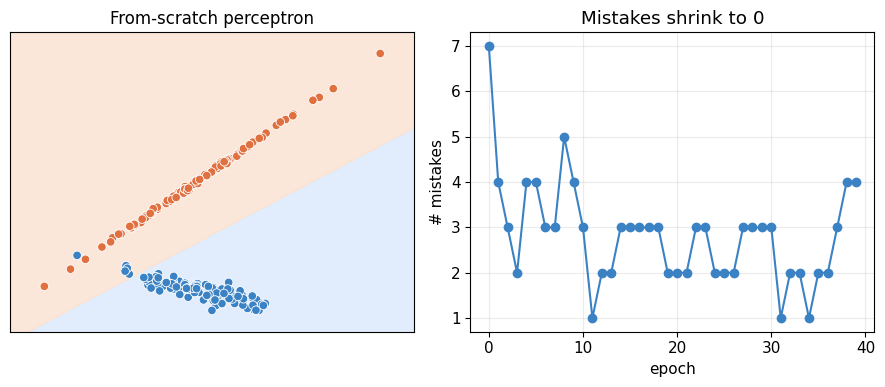

In [12]:

# Implemented from scratch to make the update rule explicit
def train_perceptron(X, y, epochs=40, lr=1.0):
    y_pm = np.where(y == 0, -1, 1)  # perceptron expects +/-1 labels
    w = np.zeros(X.shape[1]); b = 0.0
    history = []
    for epoch in range(epochs):
        mistakes = 0
        for xi, yi in zip(X, y_pm):
            pred = np.sign(w @ xi + b)
            if pred == 0: pred = -1
            if pred != yi:
                w += lr * yi * xi
                b += lr * yi
                mistakes += 1
        history.append(mistakes)
        if mistakes == 0:
            break
    return w, b, history

w, b, history = train_perceptron(X_train, y_train)
print(f"Converged after {len(history)} epochs (mistakes per epoch: {history})")

class PerceptronWrapper:
    def __init__(self, w, b): self.w, self.b = w, b
    def predict(self, X): return (X @ self.w + self.b >= 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_boundary(PerceptronWrapper(w, b), X, y, title='From-scratch perceptron', ax=axes[0])
axes[1].plot(history, 'o-', color=COLOR_A)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('# mistakes'); axes[1].set_title('Mistakes shrink to 0')
plt.tight_layout(); plt.show()



## 13. Neural Network (MLP)

Stack Perceptron-like units into layers:

$$h = \varphi(W_1 x + b_1), \qquad \hat y = \varphi(W_2 h + b_2)$$

**Why the nonlinearity $\varphi$ is essential.** Without it, $\hat y = W_2(W_1 x + b_1) + b_2 = (W_2W_1)x + (W_2b_1+b_2)$
— algebraically still just one linear function, no matter how many layers you stack. $\varphi$ (sigmoid, tanh, ReLU,
...) is what stops consecutive linear layers from collapsing into one, letting the network bend a line into a curve.

**Training — backpropagation.** The chain rule lets us compute $\partial \mathcal L/\partial w$ for *every* weight
in the network by propagating the output error backward layer by layer, reusing intermediate derivatives instead of
recomputing them from scratch for each weight. This is what makes training deep networks computationally feasible.

**Universal approximation.** A single hidden layer with enough units can approximate any continuous function on a
bounded domain arbitrarily closely — in principle. In practice, *depth* (many modest layers) tends to learn more
efficiently than *width* (one huge layer) for the same total number of parameters.

**Overfitting risk.** With enough neurons, an MLP can memorize the training set outright. Dropout, weight decay
(L2), and early stopping are the standard countermeasures.


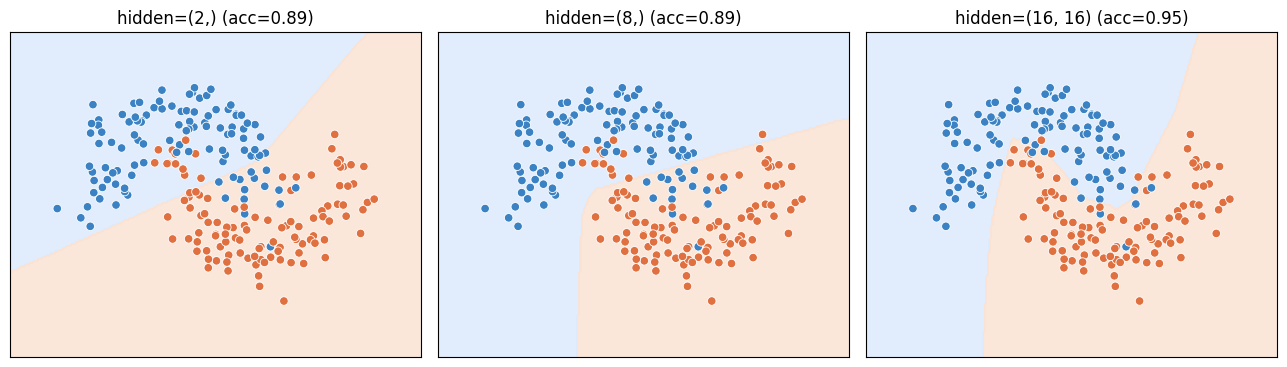

In [13]:

from sklearn.neural_network import MLPClassifier

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, hidden in zip(axes, [(2,), (8,), (16, 16)]):
    mlp = MLPClassifier(hidden_layer_sizes=hidden, activation='relu', max_iter=3000, random_state=42).fit(Xm_train, ym_train)
    acc = mlp.score(Xm_test, ym_test)
    plot_boundary(mlp, X_moon, y_moon, title=f'hidden={hidden} (acc={acc:.2f})', ax=ax)
plt.tight_layout(); plt.show()



## 14. Gradient Boosting

Build an additive ensemble **sequentially**, where each new model targets the current ensemble's mistakes:

$$F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$$

**Why this is "gradient" descent.** Think of $F$ not as a set of parameters but as a function itself, living in an
infinite-dimensional function space. The "gradient" of the loss with respect to $F$, evaluated at the current
predictions, is a vector of residuals — and $h_m$ is trained to point in that steepest-descent direction. That's why
fitting each new tree to the *residual error* of the current ensemble is mathematically gradient descent, just
performed in function space instead of parameter space.

**Learning rate $\nu$.** Small $\nu$ takes smaller, more cautious steps — more trees are needed, but the final
ensemble generalizes better (a form of regularization). This is the classic *shrinkage* trick.

Unlike Random Forest (parallel, independent trees averaged together), boosting trees are strictly sequential —
each one depends on all the ones before it, so training can't be parallelized across trees.


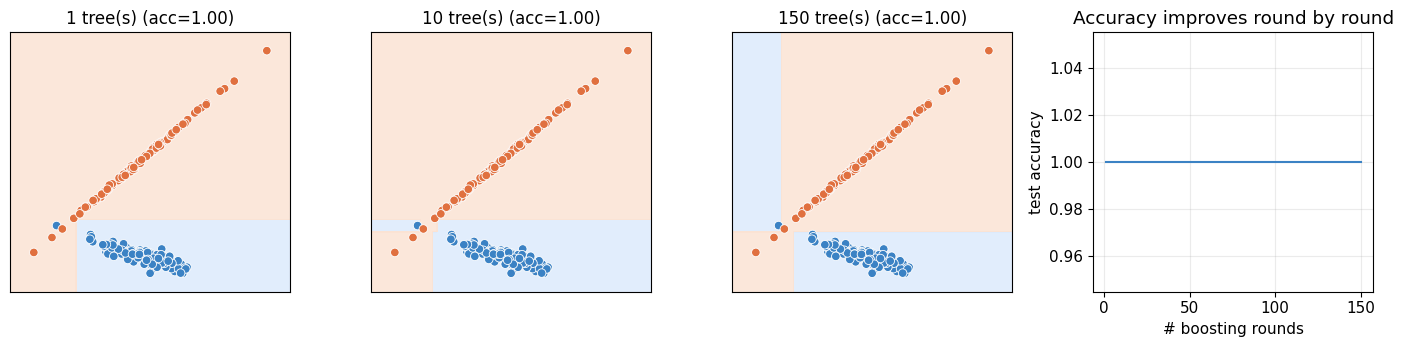

In [14]:

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.15, max_depth=2, random_state=42).fit(X_train, y_train)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, m in zip(axes[:3], [1, 10, 150]):
    gb_m = GradientBoostingClassifier(n_estimators=m, learning_rate=0.15, max_depth=2, random_state=42).fit(X_train, y_train)
    plot_boundary(gb_m, X, y, title=f'{m} tree(s) (acc={gb_m.score(X_test,y_test):.2f})', ax=ax)

staged_preds = list(gb.staged_predict(X_test))
test_acc = [np.mean(pred == y_test) for pred in staged_preds]
axes[3].plot(range(1, gb.n_estimators + 1), test_acc, color=COLOR_A)
axes[3].set_xlabel('# boosting rounds'); axes[3].set_ylabel('test accuracy')
axes[3].set_title('Accuracy improves round by round')
plt.tight_layout(); plt.show()



## 15. AdaBoost

Combine many **weak learners** (often depth-1 "stumps") into a strong one, reweighting the training data after
every round so misclassified points get more attention next time.

**The math.** After round $m$, compute the weighted error rate $\text{err}_m$ and set:

$$\alpha_m = \tfrac12 \ln\!\left(\frac{1-\text{err}_m}{\text{err}_m}\right)$$

**Why this formula.** $\alpha_m$ falls straight out of minimizing the **exponential loss** $e^{-y F(x)}$ at each
round — it is exactly the log-odds of learner $m$ being right vs. wrong. A learner that's only slightly better than
chance ($\text{err}_m \approx 0.5$) gets $\alpha_m \approx 0$ (barely counted); a highly accurate learner gets a
large, confident weight. Final prediction:

$$\hat y = \text{sign}\left(\sum_m \alpha_m h_m(x)\right)$$

Sample weights update multiplicatively: misclassified points get multiplied by $e^{\alpha_m}$ (heavier), correctly
classified points by $e^{-\alpha_m}$ (lighter), then renormalized.

**Caution.** Because misclassified points keep gaining weight, outliers and mislabeled data get *increasingly*
emphasized — AdaBoost is notably more sensitive to noisy labels than bagged methods like Random Forest.


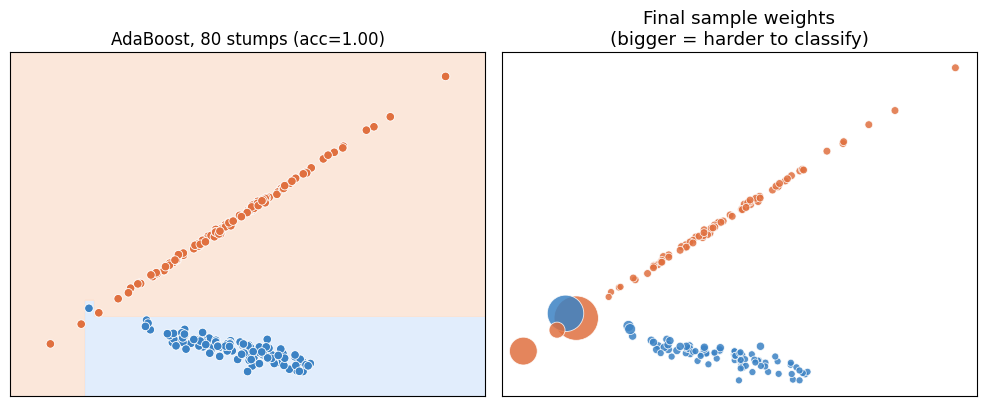

In [15]:

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=80, random_state=42).fit(X_train, y_train)

# Recover the *final* sample weights by replaying AdaBoost's own reweighting scheme
sample_weight = np.ones(len(X_train)) / len(X_train)
for est in ada.estimators_:
    pred = est.predict(X_train)
    incorrect = (pred != y_train)
    err = np.sum(sample_weight * incorrect) / np.sum(sample_weight)
    err = np.clip(err, 1e-10, 1 - 1e-10)
    alpha = 0.5 * np.log((1 - err) / err)
    sample_weight *= np.exp(alpha * np.where(incorrect, 1, -1))
    sample_weight /= sample_weight.sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
plot_boundary(ada, X, y, title=f'AdaBoost, 80 stumps (acc={ada.score(X_test,y_test):.2f})', ax=axes[0])
sizes = 25 + 3000 * sample_weight
axes[1].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=CMAP_BOLD, s=sizes, edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].set_title('Final sample weights\n(bigger = harder to classify)')
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout(); plt.show()



## 16. XGBoost, LightGBM, CatBoost

All three are gradient boosting engines — same additive-model idea as above — with different engineering choices.

**XGBoost's key addition** is folding regularization directly into the objective being optimized at every split,
not just applying it after the fact:

$$\text{Obj} = \sum_i l(y_i, \hat y_i) + \sum_k \Omega(f_k), \qquad \Omega(f) = \gamma T + \tfrac12 \lambda \sum_j w_j^2$$

where $T$ is the number of leaves and $w_j$ are the leaf weights. **Why:** a tree that fits training data
marginally better by adding more leaves now has to "pay" for that complexity ($\gamma T$) and for large leaf
weights ($\lambda \sum w_j^2$) inside the very objective the optimizer is trying to minimize — Occam's razor baked
directly into the math, not bolted on afterward.

| | Growth strategy | Standout feature | Best for |
|---|---|---|---|
| **XGBoost** | depth-wise (level by level) | regularized objective (above) | reliable general-purpose choice |
| **LightGBM** | leaf-wise (grows the most-improving leaf first) | histogram binning of features | speed on very large tabular data |
| **CatBoost** | symmetric, ordered boosting | native categorical feature handling | data with many categorical columns |


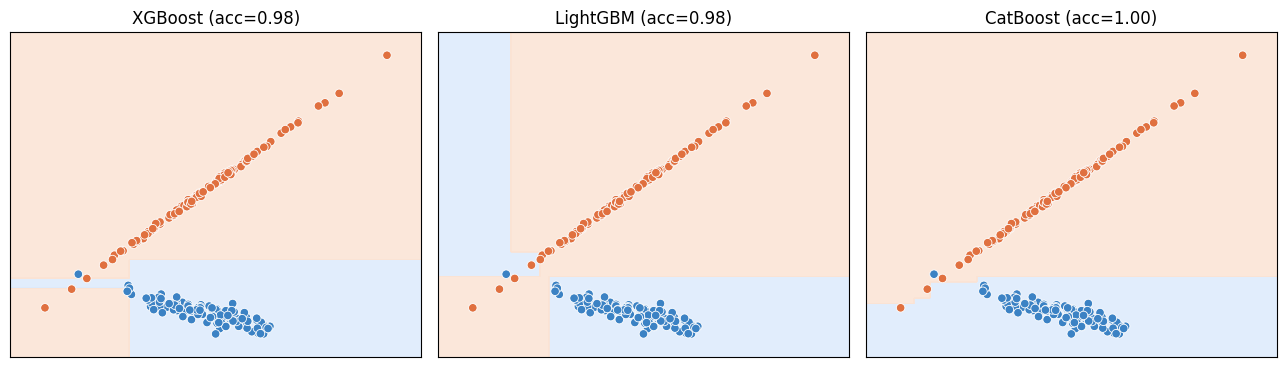

,model,test_accuracy,fit_time_sec
0,XGBoost,0.982,0.010
1,LightGBM,0.982,0.021
2,CatBoost,1.000,0.076


In [16]:

import time
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    'XGBoost':  XGBClassifier(n_estimators=100, max_depth=3, eval_metric='logloss', verbosity=0, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=3, verbosity=-1, random_state=42),
    'CatBoost': CatBoostClassifier(n_estimators=100, depth=3, verbose=False, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
rows = []
for ax, (name, model) in zip(axes, models.items()):
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - t0
    acc = model.score(X_test, y_test)
    rows.append({'model': name, 'test_accuracy': round(acc, 3), 'fit_time_sec': round(fit_time, 3)})
    plot_boundary(model, X, y, title=f'{name} (acc={acc:.2f})', ax=ax)
plt.tight_layout(); plt.show()

pd.DataFrame(rows)



## 17. Stochastic Gradient Descent (SGD) Classifier

A **training strategy**, not a model architecture — it can drive a linear model with any differentiable loss
(log-loss → logistic regression, hinge loss → linear SVM, ...).

**Batch gradient descent** update: $w \leftarrow w - \eta \nabla_w \mathcal L(w; X, y)$, using *every* training
example to compute one gradient step. **Stochastic** gradient descent instead uses one example (or a small
mini-batch) at a time:

$$w \leftarrow w - \eta \nabla_w \mathcal L(w; x_i, y_i)$$

**Why this still works.** The full-batch gradient is the *average* gradient over all examples. A single example's
gradient is a noisy but **unbiased estimator** of that same average — its expected value equals the true gradient.
So on average, each step still points downhill, even though any individual step might zig-zag.

**Why it matters practically.** Computing an exact gradient over millions of rows is expensive and may not even fit
in memory; a mini-batch gradient is nearly free by comparison, letting SGD scale to web-scale and streaming data
where full-batch methods simply cannot run.

**Practical notes.** SGD is sensitive to feature scale (standardize first) and to the learning rate — a fixed rate
either overshoots (too high) or crawls (too low), so a **decaying schedule** (start high, shrink over time) usually
works better.


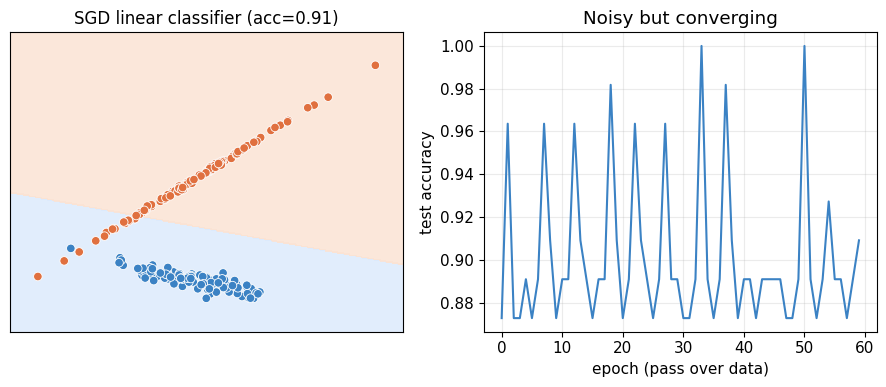

In [17]:

from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(X)
Xs_train, Xs_test, ys_train, ys_test = train_test_split(Xs, y, test_size=0.25, random_state=42, stratify=y)

sgd = SGDClassifier(loss='log_loss', learning_rate='optimal', max_iter=1, tol=None, warm_start=True, random_state=42)
test_acc_per_epoch = []
for epoch in range(60):
    sgd.fit(Xs_train, ys_train)
    test_acc_per_epoch.append(sgd.score(Xs_test, ys_test))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_boundary(sgd, Xs, y, title=f'SGD linear classifier (acc={test_acc_per_epoch[-1]:.2f})', ax=axes[0])
axes[1].plot(test_acc_per_epoch, color=COLOR_A)
axes[1].set_xlabel('epoch (pass over data)'); axes[1].set_ylabel('test accuracy')
axes[1].set_title('Noisy but converging')
plt.tight_layout(); plt.show()



## 18. Regularization (L1 vs L2)

Add a penalty term proportional to weight magnitude directly into the training loss:

$$\text{L1 (Lasso):}\quad \mathcal L + \lambda \sum_j |w_j| \qquad\qquad \text{L2 (Ridge):}\quad \mathcal L + \lambda \sum_j w_j^2$$

**Why they behave differently.** Picture the constraint regions: L1's is a diamond (sharp corners on the axes), L2's
is a smooth circle/ellipsoid. The loss function's contours are most likely to first touch the constraint region
exactly *at a corner* for L1 — and corners of a diamond sit on the axes, i.e. some coordinates are exactly zero.
L2's smooth boundary has no such corners, so it shrinks every weight toward zero without ever landing exactly on it.

- **L2 (Ridge):** shrinks every weight smoothly — good when most features contribute a little.
- **L1 (Lasso):** drives weak weights to exactly zero — performs automatic feature selection.
- **Elastic Net** blends both: $\lambda_1\sum|w_j| + \lambda_2\sum w_j^2$ — sparse like L1, stable like L2.

$\lambda$ controls the fit-vs-simplicity trade-off directly — it's the same knob from the Bias-Variance section:
too large underfits, too small brings back overfitting.


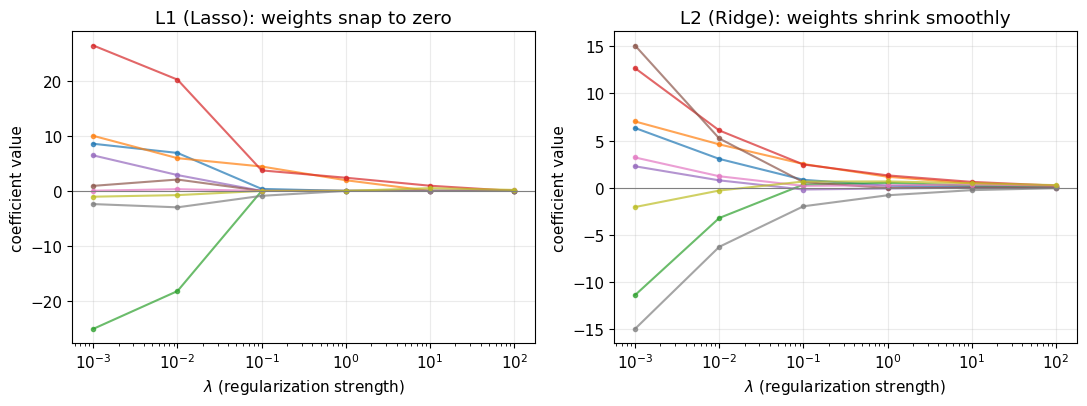

Non-zero coefficients at strongest L1 penalty: 2 / 9


In [18]:

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures

# Use a higher-degree polynomial feature expansion so there are enough coefficients to show shrinkage
poly = PolynomialFeatures(degree=3, include_bias=False)
Xp_train = poly.fit_transform(X_train)
Xp_test = poly.transform(X_test)

lambdas = [0.001, 0.01, 0.1, 1, 10, 100]
l1_coefs, l2_coefs = [], []
for lam in lambdas:
    C = 1 / lam
    m1 = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=5000).fit(Xp_train, y_train)
    m2 = LogisticRegression(penalty='l2', solver='liblinear', C=C, max_iter=5000).fit(Xp_train, y_train)
    l1_coefs.append(m1.coef_[0])
    l2_coefs.append(m2.coef_[0])
l1_coefs, l2_coefs = np.array(l1_coefs), np.array(l2_coefs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for j in range(l1_coefs.shape[1]):
    axes[0].plot(lambdas, l1_coefs[:, j], marker='o', ms=3, alpha=0.7)
    axes[1].plot(lambdas, l2_coefs[:, j], marker='o', ms=3, alpha=0.7)
for ax, title in zip(axes, ['L1 (Lasso): weights snap to zero', 'L2 (Ridge): weights shrink smoothly']):
    ax.set_xscale('log'); ax.set_xlabel(r'$\lambda$ (regularization strength)'); ax.set_ylabel('coefficient value')
    ax.set_title(title); ax.axhline(0, color='gray', lw=0.8)
plt.tight_layout(); plt.show()

print("Non-zero coefficients at strongest L1 penalty:", np.sum(np.abs(l1_coefs[-1]) > 1e-6), "/", l1_coefs.shape[1])



## 19. Multi-Class Strategies

Many classifiers (SVM, logistic regression, Perceptron) are inherently binary. To handle $k > 2$ classes:

**One-vs-Rest (OvR).** Train $k$ binary classifiers, each answering "is it class $i$ or not?" Predict the class
whose classifier is most confident:

$$\hat y = \arg\max_i \; f_i(x)$$

**One-vs-One (OvO).** Train a classifier for every pair of classes — $\binom{k}{2} = \dfrac{k(k-1)}{2}$ classifiers
total — and let them vote.

**The trade-off.** OvR trains fewer models, but each one faces an imbalanced problem (1 class vs. everyone else
combined). OvO trains more models, but each only ever sees two classes at a time — often cleaner individual
boundaries, at the cost of $O(k^2)$ training time instead of $O(k)$.

Many algorithms (Decision Trees, Random Forest, Naive Bayes, softmax-output neural nets) handle multi-class
*natively* and don't need either strategy.


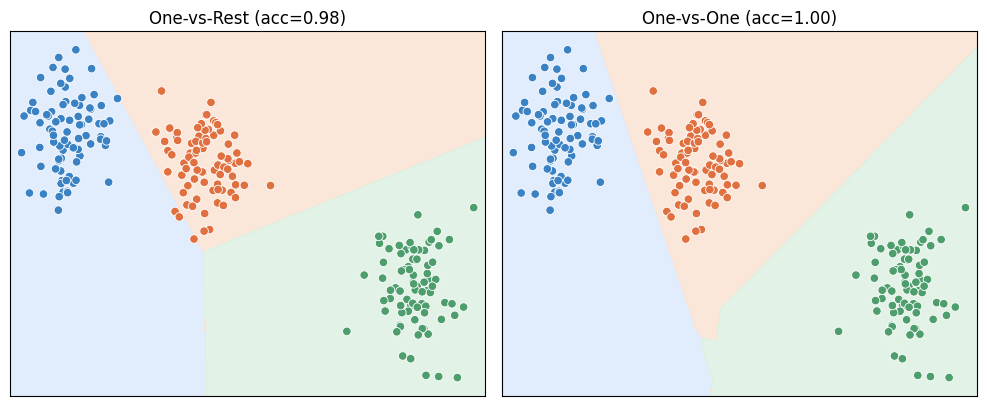

OvR trains 3 classifiers; OvO trains 3 classifiers (k=3 classes)


In [19]:

from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.svm import LinearSVC

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.25, random_state=42, stratify=y3)

ovr = OneVsRestClassifier(LinearSVC(max_iter=5000)).fit(X3_train, y3_train)
ovo = OneVsOneClassifier(LinearSVC(max_iter=5000)).fit(X3_train, y3_train)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
plot_boundary(ovr, X3, y3, title=f'One-vs-Rest (acc={ovr.score(X3_test,y3_test):.2f})', ax=axes[0], cmap_light=CMAP_LIGHT3, cmap_bold=CMAP_BOLD3)
plot_boundary(ovo, X3, y3, title=f'One-vs-One (acc={ovo.score(X3_test,y3_test):.2f})', ax=axes[1], cmap_light=CMAP_LIGHT3, cmap_bold=CMAP_BOLD3)
plt.tight_layout(); plt.show()

print(f"OvR trains {len(ovr.estimators_)} classifiers; OvO trains {len(ovo.estimators_)} classifiers (k=3 classes)")



## 20. Confusion Matrix, Precision, Recall, F1

Every binary prediction lands in one of four buckets:

|  | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

$$\text{Precision} = \frac{TP}{TP+FP} \qquad \text{Recall} = \frac{TP}{TP+FN} \qquad F_1 = \frac{2 \cdot P \cdot R}{P + R}$$

**Precision** answers "of what I flagged positive, how much was right?" **Recall** answers "of everything actually
positive, how much did I catch?" They trade off against each other as the decision threshold moves.

**Why $F_1$ uses the harmonic mean, not the arithmetic mean.** The harmonic mean is dominated by the *smaller* of
the two numbers — $F_1$ stays low if either precision or recall is low, so a model can't hide a terrible recall
behind a great precision (which a simple average would let it do).

**The accuracy paradox.** $\text{Accuracy} = (TP+TN)/\text{total}$ looks great even at 99% when positives are rare
— a model that always predicts "negative" scores 99% accuracy on a dataset that's 99% negative, while catching
*zero* positives. This is exactly why precision/recall/F1 exist.


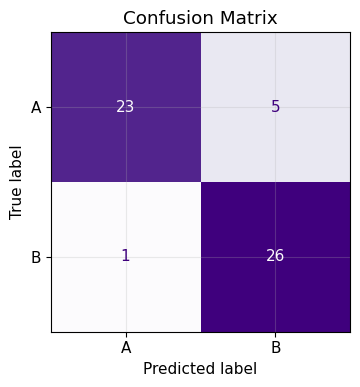

Precision: 0.839
Recall:    0.963
F1:        0.897


In [20]:

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# A linear model on the (non-linear) moons data will genuinely misclassify some
# points -- a more honest demo than a classifier that gets everything right.
clf = LogisticRegression().fit(Xm_train, ym_train)
y_pred = clf.predict(Xm_test)

cm = confusion_matrix(ym_test, y_pred)
fig, ax = plt.subplots(figsize=(4.2, 4))
ConfusionMatrixDisplay(cm, display_labels=['A', 'B']).plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Confusion Matrix')
plt.tight_layout(); plt.show()

print(f"Precision: {precision_score(ym_test, y_pred):.3f}")
print(f"Recall:    {recall_score(ym_test, y_pred):.3f}")
print(f"F1:        {f1_score(ym_test, y_pred):.3f}")



## 21. ROC Curve & AUC

Instead of committing to one decision threshold, sweep it from 1 down to 0 and plot:

$$\text{TPR} = \frac{TP}{TP+FN} \; (\text{recall}) \qquad \text{vs.} \qquad \text{FPR} = \frac{FP}{FP+TN}$$

**Why sweep the threshold.** A single precision/recall number depends entirely on where you happen to set the
cutoff. The ROC curve shows performance at *every possible* cutoff simultaneously, letting you compare two models'
underlying ranking ability independent of any one operating point.

**Reading the curve.** The diagonal ($y=x$) is what a random-guessing classifier produces. The further the curve
bows toward the top-left corner, the better the model separates the classes. **AUC** (area under the curve)
condenses the whole curve into one number: the probability that a randomly chosen positive example is ranked higher
than a randomly chosen negative one.

**Caveat.** Under heavy class imbalance, ROC/AUC can look overly optimistic (the FPR denominator is dominated by an
abundant negative class). A **Precision-Recall curve** is usually more informative in that regime.


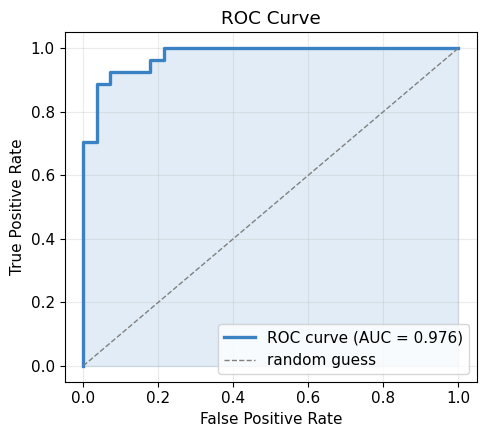

In [21]:

from sklearn.metrics import roc_curve, auc

y_score = clf.predict_proba(Xm_test)[:, 1]
fpr, tpr, thresholds = roc_curve(ym_test, y_score)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(fpr, tpr, color=COLOR_A, lw=2.4, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.fill_between(fpr, tpr, alpha=0.15, color=COLOR_A)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='random guess')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()



## 22. Summary Cheat Sheet

| Family | Algorithms | Core idea |
|---|---|---|
| Linear | Logistic Regression, Perceptron, LDA, SGD | one straight decision boundary |
| Instance-based | KNN | let nearby points vote |
| Margin-based | SVM | the widest possible separating boundary |
| Tree-based | Decision Tree, Random Forest, Extra Trees | recursive axis-aligned splits, optionally averaged |
| Probabilistic | Naive Bayes, QDA | model each class as a probability distribution |
| Boosted ensembles | Gradient Boosting, AdaBoost, XGBoost, LightGBM, CatBoost | sequentially correct the ensemble's mistakes |
| Neural | MLP | stacked linear units + nonlinearity |

Every one of these is answering the same underlying question — *which side of the line are you on* — just with a
different definition of "line," and a different way of finding it.
